In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Exercise 1b: SVD and Least Squares

**3D Computer Vision — Summer Semester 2026**

**Prof. Dr. Daniel Cremers, TU Munich**

---

In this notebook you will explore the **singular value decomposition** (SVD) through image compression, and apply least-squares fitting via the pseudo-inverse. You will also compare least-squares with PCA and understand why they give different results.

| Part | Topic | What you'll see |
|------|-------|-----------------|
| V | SVD image compression | How few singular values capture most of an image |
| VI | Least-squares vs PCA | Two ways to fit a line — and why they differ |

## Part V: SVD Image Compression

A grayscale image is just a matrix $A \in \mathbb{R}^{m \times n}$ of pixel intensities. Its SVD decomposes it into a sum of rank-1 "layers":

$$A = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^\top + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^\top + \cdots + \sigma_r \mathbf{u}_r \mathbf{v}_r^\top$$

Each layer $\sigma_i \mathbf{u}_i \mathbf{v}_i^\top$ captures a pattern of decreasing importance. The **Eckart-Young theorem** guarantees that keeping only the first $k$ terms gives the best possible rank-$k$ approximation:

$$A_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^\top, \qquad \|A - A_k\|_F^2 = \sum_{i=k+1}^{r} \sigma_i^2$$

This is also the core idea behind **PCA**: the leading singular vectors capture the directions of greatest variance in the data.

**Implement** `svd_compress` below.

In [2]:
_img = Image.open("3dcv_teaser.png").convert("L")
img_gray = np.array(_img, dtype=float) / 255.0
U_img, S_img, Vt_img = np.linalg.svd(img_gray, full_matrices=False)

In [4]:
def svd_compress(U, S, Vt, k):
    """Reconstruct a matrix using only the first k singular values.

    Args:
        U: Left singular vectors, shape (m, r).
        S: Singular values, shape (r,).
        Vt: Right singular vectors, shape (r, n).
        k: Number of singular values to keep.

    Returns:
        A_k: Rank-k approximation, shape (m, n).
    """
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    A_k = U_k @ S_k @ Vt_k
    return A_k

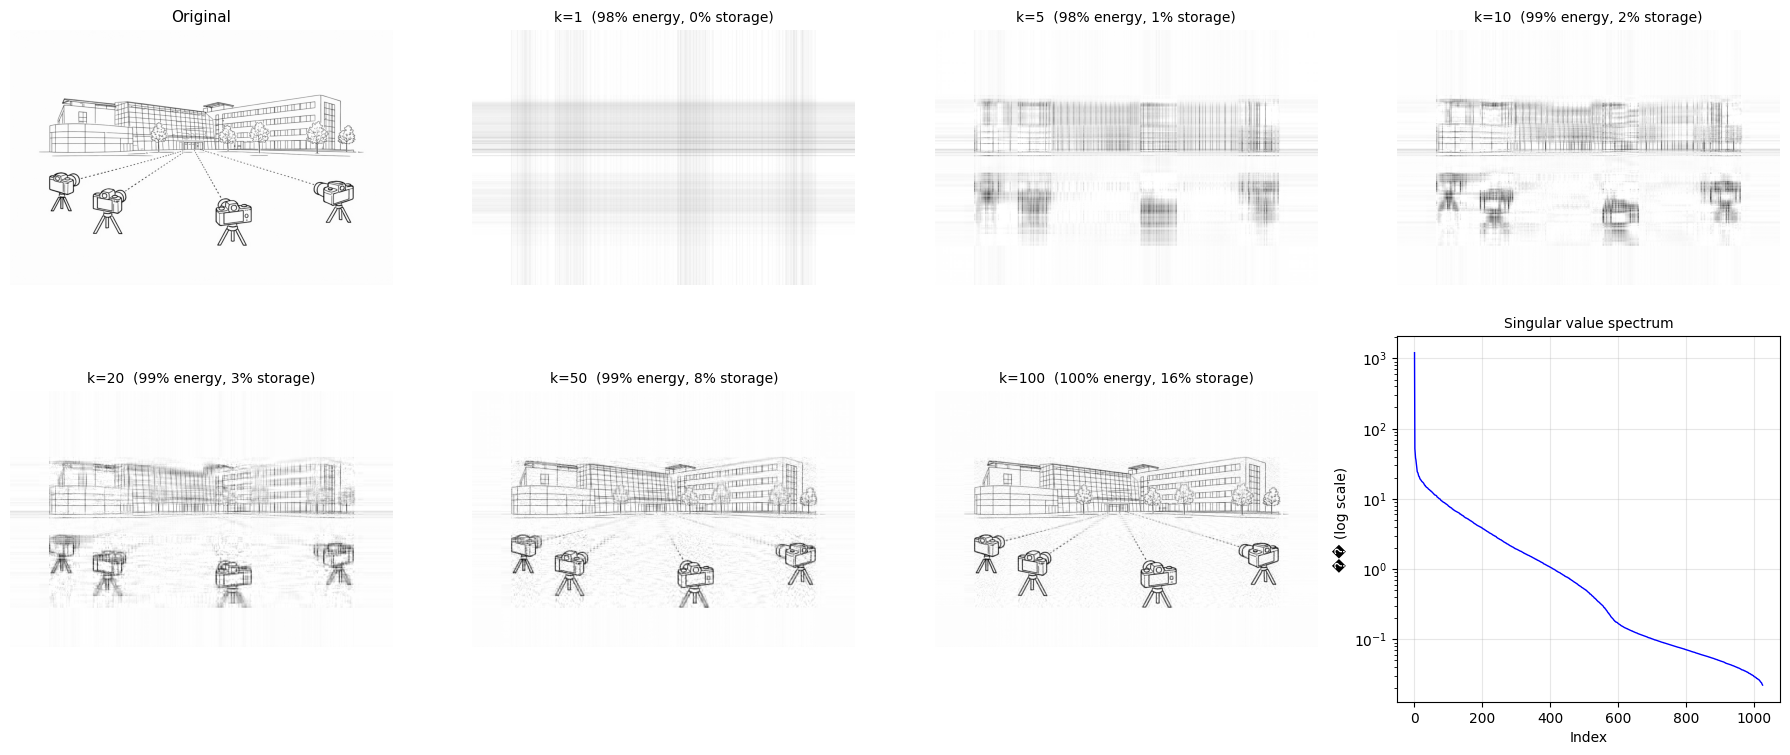

In [5]:
rank_values = [1, 5, 10, 20, 50, 100]
total_energy = np.sum(S_img**2)

_fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes[0, 0].imshow(img_gray, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original", fontsize=11)
axes[0, 0].axis("off")

for idx, k in enumerate(rank_values):
    row, col = divmod(idx + 1, 4)
    img_k = svd_compress(U_img, S_img, Vt_img, k)
    energy = np.sum(S_img[:k]**2) / total_energy * 100
    m, n = img_gray.shape
    storage = k * (m + n + 1) / (m * n) * 100
    axes[row, col].imshow(np.clip(img_k, 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[row, col].set_title(f"k={k}  ({energy:.0f}% energy, {storage:.0f}% storage)", fontsize=10)
    axes[row, col].axis("off")

axes[1, 3].semilogy(np.arange(1, len(S_img)+1), S_img, "b-", lw=1)
axes[1, 3].set_xlabel("Index")
axes[1, 3].set_ylabel("�� (log scale)")
axes[1, 3].set_title("Singular value spectrum", fontsize=10)
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part VI: Least-Squares vs PCA Line Fitting

There are two natural ways to fit a line to 2D points. They look similar but minimize **different things**.

**Method 1 — Least squares.** Model the line as $y = ax + b$ and solve the overdetermined system via the pseudo-inverse. This minimizes the **vertical** distance $\sum_i (y_i - ax_i - b)^2$.

**Method 2 — PCA.** Treat each point as a 2D vector $(x_i, y_i)$. Compute the covariance matrix and find its eigenvectors. The first eigenvector points along the direction of greatest variance — i.e. along the line. This minimizes the **orthogonal** distance from each point to the line.

**Implement both and compare.** Why are the results different?

In [6]:
np.random.seed(42)
_N = 50
_x = np.linspace(-2, 2, _N)
_y = 2.0 * _x + 1.0 + 1.5 * np.random.randn(_N)
points = np.column_stack([_x, _y])

In [7]:
def fit_line_least_squares(pts):
    """Fit y = ax + b via pseudo-inverse.

    Args:
        pts: Shape (N, 2).

    Returns:
        a, b: Line parameters.
    """
    x = pts[:, 0]
    y = pts[:, 1]
    A = np.column_stack([x, np.ones(len(x))])
    theta = np.linalg.pinv(A) @ y
    a, b = theta
    return a, b

def fit_line_pca(pts):
    """Fit a line through PCA on 2D points.

    Args:
        pts: Shape (N, 2).

    Returns:
        center: (2,) mean of points.
        direction: (2,) unit vector along principal component.
    """
    center = np.mean(pts, axis=0)
    X = pts - center
    U, S, Vt = np.linalg.svd(X)
    direction = Vt[0]
    return center, direction

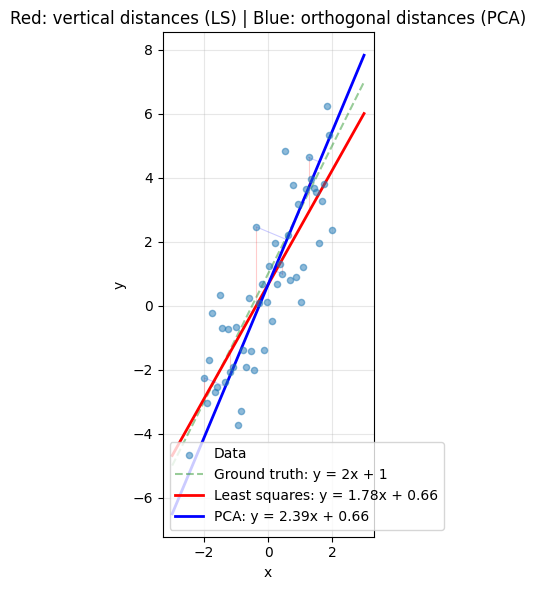

In [8]:
a, b = fit_line_least_squares(points)
center, direction = fit_line_pca(points)
a_pca = direction[1] / direction[0]
b_pca = center[1] - a_pca * center[0]

_fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(points[:, 0], points[:, 1], s=20, alpha=0.5, zorder=5, label="Data")

xf = np.linspace(-3, 3, 200)
ax.plot(xf, 2.0 * xf + 1.0, "g--", alpha=0.4, lw=1.5, label="Ground truth: y = 2x + 1")
ax.plot(xf, a * xf + b, "r-", lw=2, label=f"Least squares: y = {a:.2f}x + {b:.2f}")
ax.plot(xf, a_pca * xf + b_pca, "b-", lw=2, label=f"PCA: y = {a_pca:.2f}x + {b_pca:.2f}")

for i in range(0, len(points), 10):
    p = points[i]
    ax.plot([p[0], p[0]], [p[1], a * p[0] + b], "r-", alpha=0.2, lw=0.8)
    proj = center + np.dot(p - center, direction) * direction
    ax.plot([p[0], proj[0]], [p[1], proj[1]], "b-", alpha=0.2, lw=0.8)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=10)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.set_title("Red: vertical distances (LS) | Blue: orthogonal distances (PCA)")
plt.tight_layout()
plt.show()